## NOTEBOOK FOR PLAYING WITH THE VALUES IN THE DATA TO SIMULATION

In [2]:
%load_ext autoreload
%autoreload 2

%reload_ext autoreload

In [3]:
# Pointing the path to the import and parameter files
import sys
sys.path.insert(0, '../../')
# Import list
from imports import *
# Parameter list
import param as pm 

In [4]:
## rc parameter files

small = 12
medium = 16
big = 25

plt.rc('font', size=small)          # controls default text sizes
plt.rc('axes', titlesize=big)     # fontsize of the axes title
plt.rc('axes', labelsize=medium)    # fontsize of the x and y labels
plt.rc('xtick', labelsize=small)    # fontsize of the tick labels
plt.rc('ytick', labelsize=small)    # fontsize of the tick labels
plt.rc('legend', fontsize=small)    # legend fontsize
plt.rc('figure', titlesize=big)  # fontsize of the figure title

### Attenuation function


#### Gaussian taper

In [6]:
fx = np.arange(1100, 1300, 0.1)
fy = 3*(fx-1200)**2 + 2*fx

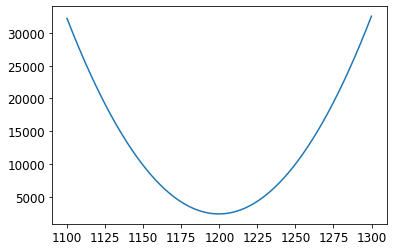

In [6]:
plt.plot(fx, fy)

In [9]:
af.gaussian_oob

<function satellite_RFI.src.attenuation_function.gaussian_oob(f, fi, band, sigma, values)>

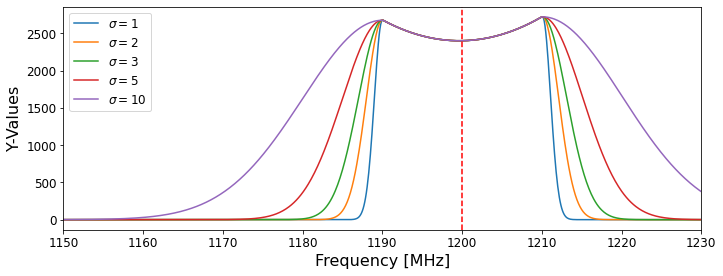

In [8]:
plt.figure(figsize=(10,4))
for sig_i in [1,2,3,5,10]:
    goob = af.gaussian_oob(f=fx, fi=1200, band=10, sigma=sig_i, values=fy)
    plt.plot(fx, goob, label=r'$\sigma=$'+str(sig_i))
plt.axvline(1200, color='r', ls='--')

plt.xlabel('Frequency [MHz]')
plt.ylabel('Y-Values')
plt.legend()
plt.tight_layout()
plt.xlim([1150,1230])
# plt.savefig(pm.data_plot+'fitting/attenuation_funtion_goob.pdf', bbox_inches='tight')
plt.show()

#### Equation 3.3: Smoothed top-hat window

$W(z, z_i \Delta z_i, \sigma_{z}) = \dfrac{1}{2 tanh(\Delta z_{i}/2\sigma_{z_i})} \bigg [tanh \bigg( \dfrac{z-z_i + \Delta z_i /2}{\sigma_{z_i}}\bigg) - tanh\bigg(\dfrac{z-z_i - \Delta z_i/2}{\sigma_{z_i}}\bigg) \bigg] $

In [6]:
def sthw(f, fi, band, sigma):
    a=1/(2*np.tanh(band/(2*sigma)))
    b=np.tanh((f-fi+band/2)/sigma)
    c=np.tanh((f-fi-band/2)/sigma)

    return a*(b-c)

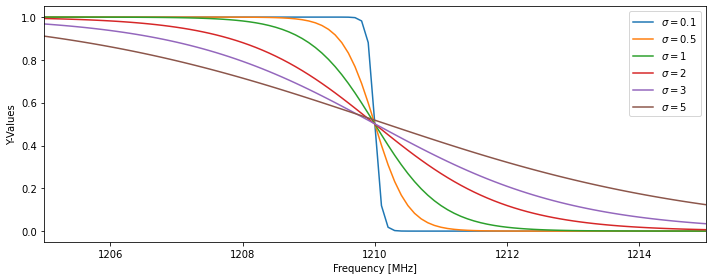

In [7]:
plt.figure(figsize=(10,4))
for sig_i in [0.1,0.5,1,2,3,5]:
    stw = sthw(f=fx, fi=1200, band=20, sigma=sig_i)
    plt.plot(fx, stw, label=r'$\sigma=$'+str(sig_i))
plt.axvline(1200, color='r', ls='--')

plt.xlabel('Frequency [MHz]')
plt.ylabel('Y-Values')
plt.legend()
plt.tight_layout()
plt.xlim([1205,1215])
plt.savefig(pm.data_plot+'fitting/attenuation_funtion_sthw.pdf', bbox_inches='tight')
plt.show()

### Chi Square Functions

In [4]:
## DATE, OBSERVATION NAME, FREQUENCY SLICES, FOLDER FOR SAVING
fname, dtime=tools.timepoint(fname=pm.file, date=None)
fs_slice=pm.fs_slice
fe_slice=pm.fe_slice
ts_slice=pm.ts_slice
te_slice=pm.te_slice


##FREQUENCY
print ('Frequeny range: '+str(fs_slice)+'-'+str(fe_slice)+' MHz')

##TIME
print ('Time range: '+str(ts_slice)+'-'+str(te_slice)+' seconds')

##MASK
if pm.mask==False:
    print ('Mask: No')
else:
    print ('Mask: Yes')
    print ('Degree masking: '+str(pm.degree))
    

##DAMPNER
print ('Dampner value: ',pm.dampner)
if pm.dampner!=None:
    print ('Dampner sigma level: '+str(pm.dampner_sigma))
    

Date of observation: 2019-02-25 02:40:11
Fname: 1551055211
Frequeny range: 1100-1350 MHz
Time range: 775-1000 seconds
Mask: No
Dampner value:  goob
Dampner sigma level: 3


### Test: Check s_param follows same length as a_param

In [5]:
"""INITIALIZING THE SATELLITE FUNCTION"""
sat = ss(file_name=fname,          
             sats_only=None, 
             data_loc=pm.data_save, 
             sat_loc=pm.data_save,
             survey_info=[pm.nd_s0, pm.nd_s0_coords, pm.frequency], 
             sat_info=pm.satellite_catalogue,
             plots_loc=pm.data_plot,
             sat_beam=pm.beam_model+'_beam_'+str(pm.fs)+'_'+str(pm.fe)+'MHz', 
             frequency_range=[pm.fs, pm.fe], 
             constellations=pm.constellations_remain,
             nearby_satellites=pm.nearby_constellations,
             verbose=False)

In [6]:
sat.alpha_len

31

In [7]:
aparam = np.ones(21)

In [8]:
sat.excecute(a_param=aparam, 
             obs_time_start=ts[0], obs_time_end=te[0], 
             obs_frequency_start=pm.fs_slice, obs_frequency_end=pm.fe_slice, 
             file_bias_choice=pm.bias, 
             add_sub=[1, 1], 
             attenuation_func='goob',
             attenuation_sigma=np.ones(21), 
             bandsize=None,
             verbose=True)

NameError: name 'ts' is not defined

In [ ]:
sat.alpha_len

### End of test: 

In [ ]:
##CHI SQAURE METHOD
def chisq_func2(a_param, s_param=None, damper=None, frequency_slice=False, time_slice=False, t_mask=False, d_mask=False ,time_avg=False, chi_sigma=False, verbose=False):
    
    """INITIALIZING THE SATELLITE FUNCTION"""
    sat = ss(file_name=fname,          
                 sats_only=None, 
                 data_loc=pm.data_save, 
                 sat_loc=pm.data_save,
                 survey_info=[pm.nd_s0, pm.nd_s0_coords, pm.frequency], 
                 sat_info=pm.satellite_catalogue,
                 plots_loc=pm.data_plot,
                 sat_beam=pm.beam_model+'_beam_'+str(pm.fs)+'_'+str(pm.fe)+'MHz', 
                 frequency_range=[pm.fs, pm.fe], 
                 constellations=pm.constellations_remain,
                 nearby_satellites=pm.nearby_constellations,
                 verbose=False)
    
    """EXCECUTING THE THE SATELLITE SIM FUNCTION"""
    sat.excecute(a_param=a_param, 
                 obs_time_start=time_slice[0], obs_time_end=time_slice[1], 
                 obs_frequency_start=frequency_slice[0], obs_frequency_end=frequency_slice[1], 
                 file_bias_choice=pm.bias, 
                 add_sub=[1, 1], 
                 attenuation_func=damper, 
                 attenuation_sigma=s_param, 
                 bandsize=None,
                 verbose=False)

    """FREQUENCY SLICE"""
    frange_slice = sat.frequency_band[sat.frequency_idx[0]:sat.frequency_idx[1]]  
    
    """MASKING"""
    ## TEMPERATURE MASKING 
    if t_mask!=False and d_mask==False:
        print ('Temperature mask of '+str(t_mask)+' Kelvin')
        zero_arr = np.zeros(sat.calibration_data_slice.shape)
        mask_idx = np.where(sat.calibration_data_slice > t_mask)

        zero_arr[mask_idx]=1
        simulation = np.ma.array(data=sat.simulation_TOD_slice.T, mask=zero_arr.T)    #SIMULATIONS
        data = np.ma.array(data=sat.calibration_data_slice.T, mask=zero_arr.T)  #DATA

    ## DEGREE MASKING
    elif d_mask!=False and t_mask==False:
        print ("Area mask of "+str(d_mask)+" degrees")
        simulation = np.ma.array(data=sat.simulation_TOD_slice.T, mask=sat.mask_nearby_satellites_slice)
        data = np.ma.array(data=sat.calibration_data_slice.T, mask=sat.mask_nearby_satellites_slice)
    
    ## NO MASKING
    else:
        print ("No masking applied")
        simulation = np.ma.array(data=sat.simulation_TOD_slice.T, mask=None)
        data = np.ma.array(data=sat.calibration_data_slice.T, mask=None)
        
    """TIME AVERAGING"""
    if time_avg!=False:
        print ("Time averageing for every "+str(time_avg)+" seconds")
        #Averaging over time - MISSING TIMER PARAMETER
        data = tools.waterfall_avg_time(timer=pm.nd_s0, size=20, waterfall=data)
        simulation = tools.waterfall_avg_time(timer=pm.nd_s0, size=20, waterfall=simulation)
    
    """CHI SQAURE NUMERATOR"""
    chi_num = simulation - data  # WANT THIS VALUE

    """CHI^2 SIGMA CHOICE"""
    if chi_sigma==True:
        sig=tools.radiometer_eq(data=data)  # Note this is sigma (expected noise level), it must be squared to give the radiometer equation
    else: 
        sig=1
    
    """CHI SQUARE VALUE"""
    chi_sq = np.ma.sum(chi_num**2 / sig**2)
      
    chi_sq_N = chi_sq /  np.ma.size(data)
    
    if verbose==True:
        print ("Chi numerator value: "+str(np.sum(chi_num)))
        print ("Chi Square value: "+str(chi_sq))
        print ("Chi Square N value: "+str(chi_sq_N))

    return data, simulation, chi_sq_N, frange_slice, sat.sat_data_adjusted

### Time regions

In [9]:
ts = [775, 2400, 5500]
te = [1000, 2600, 6200]

time_alpha = []
time_chi = []
time_chi_N = []
for times in range(len(ts)):
    st_path = '/users/bengelbrecht/hi_im/brandon/meerkat_gain_cali/1551055211/sat_2/'
    stf_name = 'full_no_mask_satellite_f_1000_1500MHz__1100_1350MHz_'+str(ts[times])+'_'+str(te[times])+'_sec_v2.p'
    
    dic_vals = pickle.load(open(st_path+stf_name, 'rb'))
    print ('Time: '+str(ts[times])+'-'+str(te[times])+' - '+str(dic_vals['chi2_value'])+' - '+str(dic_vals['chi2_div']))
    
    time_alpha.append(dic_vals['best-fit'])
    time_chi.append(dic_vals['chi2_value'])
    time_chi_N.append(dic_vals['chi2_div'])

Time: 775-1000 - 57068.549596660305 - 0.5534510308654529
Time: 2400-2600 - 158145.35604091513 - 1.7129572916923748
Time: 5500-6200 - 359342.8331355926 - 1.0898258643887864


In [10]:
time_alpha[0].shape

(21,)

#### No attenuation

In [16]:
data_time, sim_time = [], []
for times in range(len(ts)):
    vals = chisq_func2(a_param=time_alpha[times], damper=None, frequency_slice=[1100, 1350], time_slice=[ts[times], te[times]], verbose=False)
    data_time.append(vals[0])
    sim_time.append(vals[1])
    fslice = vals[3]

No masking applied
No masking applied
No masking applied


#### Attenuation

In [17]:
sigma_level = [pm.dampner_sigma]

a_sigma = []
for sil in sigma_level:
    asim_time = []
    for times in range(len(ts)):
        vals = chisq_func2(a_param=time_alpha[times], 
                           s_param=pm.dampner_sigma*np.ones(21),
                           damper='goob',
                           frequency_slice=[1100, 1350], 
                           time_slice=[ts[times], te[times]], verbose=False)
        asim_time.append(vals[1])
        fslice = vals[3]
    a_sigma.append(asim_time)

No masking applied
No masking applied
No masking applied


#### Plots

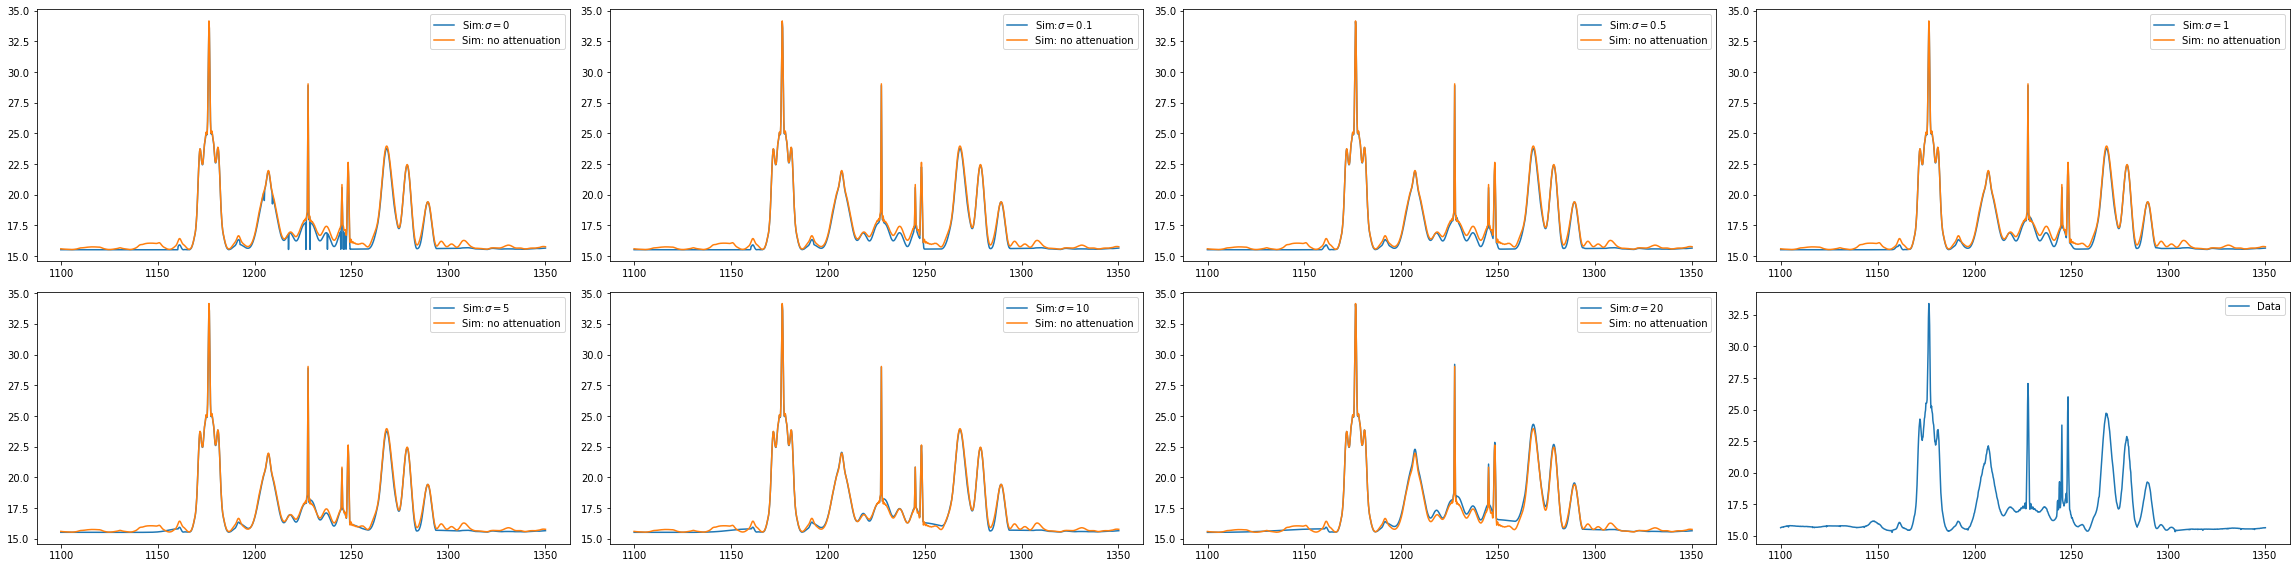

In [16]:
fig, axs = plt.subplots(figsize=(32, 8), nrows=2, ncols=4)
    
for si, sval in enumerate(sigma_level):
    
    if si>3:
        row=1
        col=si-4
    else:
        row=0
        col=si
    
    
    ax=axs[row, col]
    ax.plot(fslice, np.mean(a_sigma[si][0], axis=0), label = r'Sim:$\sigma=$'+str(sigma_level[si]))
    ax.plot(fslice, np.mean(sim_time[0], axis=0), label = r'Sim: no attenuation')
    ax.legend()
    
ax=axs[1,3]
ax.plot(fslice, np.mean(data_time[0], axis=0), label = r'Data')
ax.legend()


fig.tight_layout()

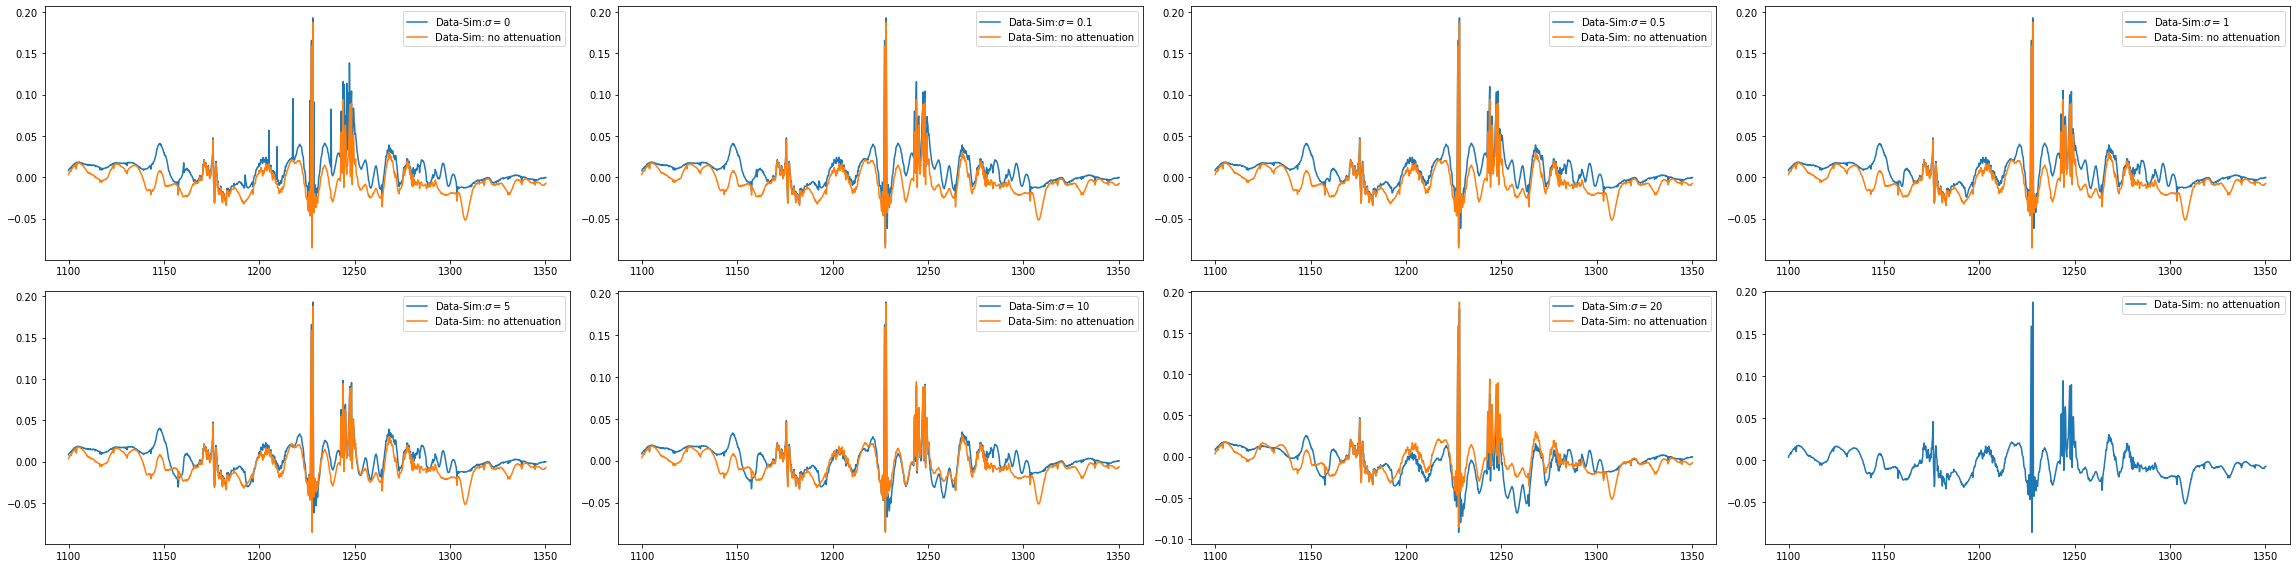

In [114]:
fig, axs = plt.subplots(figsize=(32, 8), nrows=2, ncols=4)
    
for si, sval in enumerate(sigma_level):
    
    if si>3:
        row=1
        col=si-4
    else:
        row=0
        col=si
    
    
    ax=axs[row, col]
    ax.plot(fslice, np.mean((data_time[0]-a_sigma[si][0]) / data_time[0], axis=0), label = r'Data-Sim:$\sigma=$'+str(sigma_level[si]))
    ax.plot(fslice, np.mean((data_time[0]-sim_time[0]) / data_time[0], axis=0), label = r'Data-Sim: no attenuation')
    ax.legend()
    
ax=axs[1,3]
ax.plot(fslice, np.mean((data_time[0]-sim_time[0]) / data_time[0], axis=0), label = r'Data-Sim: no attenuation')
ax.legend()


fig.tight_layout()

In [149]:
time_c = 0

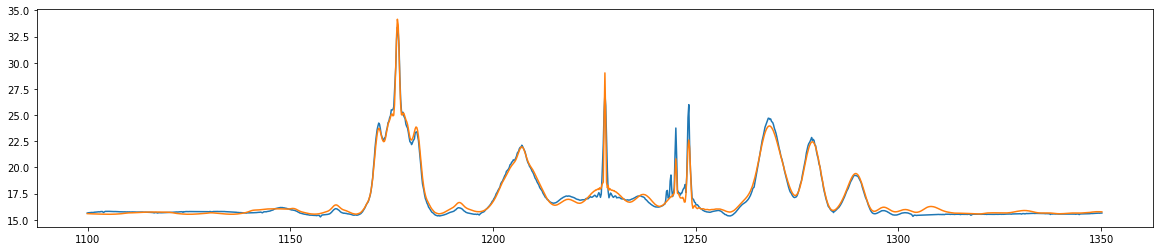

In [154]:
plt.figure(figsize=(20, 4))
plt.plot(fslice, np.mean(data_time[time_c], axis=0))
plt.plot(fslice, np.mean(sim_time[time_c], axis=0))
# plt.plot(fslice, np.mean(asim_time[0], axis=0))

(15.0, 35.0)

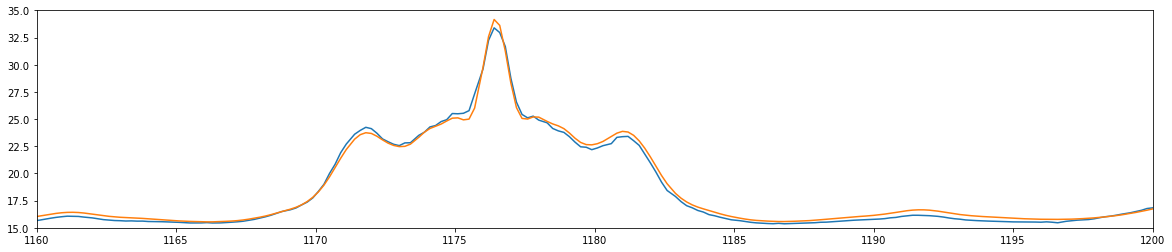

In [151]:
plt.figure(figsize=(20, 4))
plt.plot(fslice, np.mean(data_time[time_c], axis=0))
plt.plot(fslice, np.mean(sim_time[time_c], axis=0))
plt.xlim(1160, 1200)
plt.ylim(15, 35)

(15.0, 25.0)

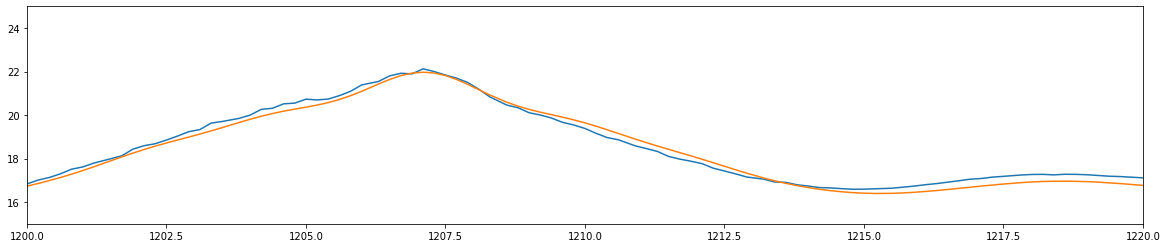

In [152]:
plt.figure(figsize=(20, 4))
plt.plot(fslice, np.mean(data_time[time_c], axis=0))
plt.plot(fslice, np.mean(sim_time[time_c], axis=0))
plt.xlim(1200, 1220)
plt.ylim(15, 25)

(15.0, 30.0)

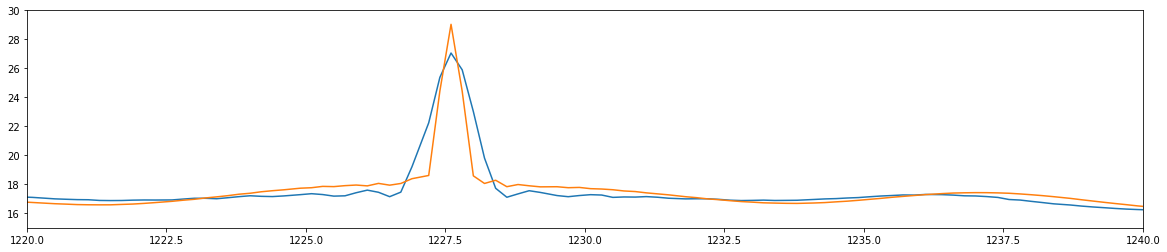

In [155]:
plt.figure(figsize=(20, 4))
plt.plot(fslice, np.mean(data_time[time_c], axis=0))
plt.plot(fslice, np.mean(sim_time[time_c], axis=0))
plt.xlim(1220, 1240)
plt.ylim(15, 30)

(15.0, 30.0)

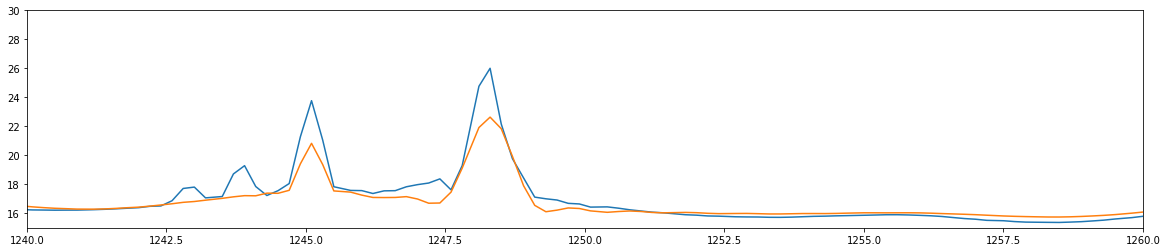

In [156]:
plt.figure(figsize=(20, 4))
plt.plot(fslice, np.mean(data_time[time_c], axis=0))
plt.plot(fslice, np.mean(sim_time[time_c], axis=0))
plt.xlim(1240, 1260)
plt.ylim(15, 30)

(15.0, 30.0)

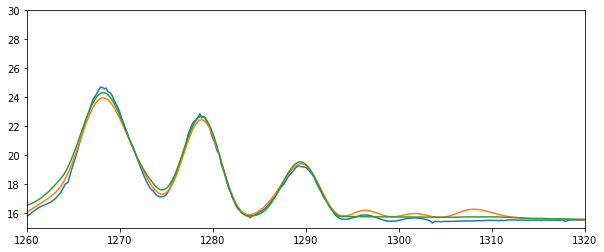

In [157]:
plt.figure(figsize=(10, 4))
plt.plot(fslice, np.mean(data_time[time_c], axis=0))
plt.plot(fslice, np.mean(sim_time[time_c], axis=0))
plt.plot(fslice, np.mean(a_sigma[6][time_c], axis=0))

plt.xlim(1260, 1320)
plt.ylim(15, 30)

### Attenuation + time of 775-100 sec

We see evidence that the attenuation is broken in determinging the values

In [16]:
at_dic_vals = []
dampner_sig = [0.1, 3, 5]
at_path = '/users/bengelbrecht/hi_im/brandon/meerkat_gain_cali/1551055211/sat_2/'

for dsi, dsv in enumerate(dampner_sig):
    atf_name = 'full_no_mask_satellite_f_1000_1500MHz__1100_1350MHz_'+str(ts[0])+'_'+str(te[0])+'_sec_goob_'+str(dsv)+'_sig1__v2.p'

    at_dic_vals.append(pickle.load(open(at_path+atf_name, 'rb')))

FileNotFoundError: [Errno 2] No such file or directory: '/users/bengelbrecht/hi_im/brandon/meerkat_gain_cali/1551055211/sat_2/full_no_mask_satellite_f_1000_1500MHz__1100_1350MHz_775_1000_sec_goob_0.1_sig1__v2.p'

##### Alpha values

NameError: name 'at_dic_vals' is not defined

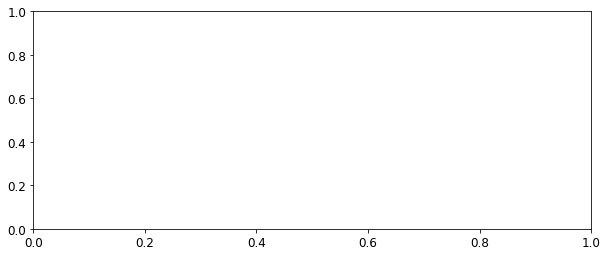

In [10]:
fig, axs = plt.subplots(figsize=(10, 4), nrows=1, ncols=1)
for i in range(3):
    ax=axs
    ax.plot(at_dic_vals[i]['best-fit'], label=r'$\sigma$='+str(dampner_sig[i]))
    
ax.plot(time_alpha[0], label=r'No attenuation')


    
ax.legend()
fig.tight_layout()
plt.show()


##### Chi Square

In [ ]:
at_sim = []
for i in range(3):
    at_sim.append(chisq_func2(a_param=at_dic_vals[i]['best-fit'], s_param=dampner_sig[i]*np.ones(len(pd.read_csv(pm.satellite_catalogue))), 
                              damper='goob', frequency_slice=[1100, 1350], time_slice=[ts[0], te[0]], t_mask=False, d_mask=False,
                              time_avg=False, chi_sigma=False, verbose=False)[1])


In [ ]:
plt.figure(figsize=(20, 4))

plt.plot(fslice, np.mean(data_time[0], axis=0))

# plt.plot(fslice, np.mean(sim_time[0], axis=0))
# plt.plot(fslice, np.mean(at_sim[0], axis=0))
# plt.plot(fslice, np.mean(at_sim[1], axis=0))
# plt.plot(fslice, np.mean(at_sim[2], axis=0))

In [ ]:
plt.figure(figsize=(20, 4))

plt.plot(fslice, np.mean(data_time[0] - sim_time[0], axis=0))
# plt.plot(fslice, np.mean(data_time[0] - at_sim[0], axis=0))
# plt.plot(fslice, np.mean(data_time[0] - at_sim[1], axis=0))
# plt.plot(fslice, np.mean(data_time[0] - at_sim[2], axis=0))

In [ ]:
plt.figure(figsize=(20, 4))

plt.plot(fslice, np.mean((data_time[0] - sim_time[0])/data_time[0], axis=0))
plt.plot(fslice, np.mean((data_time[0] - at_sim[0])/data_time[0], axis=0))
plt.plot(fslice, np.mean((data_time[0] - at_sim[1])/data_time[0], axis=0))
plt.plot(fslice, np.mean((data_time[0] - at_sim[2])/data_time[0], axis=0))

### Attenuation + 775-1000 sec + 1100-1350 MHz

In [19]:
at_path = '/users/bengelbrecht/hi_im/brandon/meerkat_gain_cali/1551055211/sat_2/'

af_file = 'full_no_mask_satellite_f_1000_1500MHz__1100_1350MHz_775_1000_sec_goob_3_sig1__v2.p'

In [49]:
goob_s3 = pickle.load(open(at_path+af_file, 'rb'))


goob_s3_d, goob_s3_s, goob_s3_chiN, fslice, sat_cat_s3  = chisq_func2(a_param=goob_s3['best-fit'], 
                                                    s_param=3*np.ones(21), damper='goob', 
                                                    frequency_slice=[1100, 1350], time_slice=[ts[0], te[0]], t_mask=False, 
                                                    d_mask=False ,time_avg=False, chi_sigma=False, verbose=False)

No masking applied


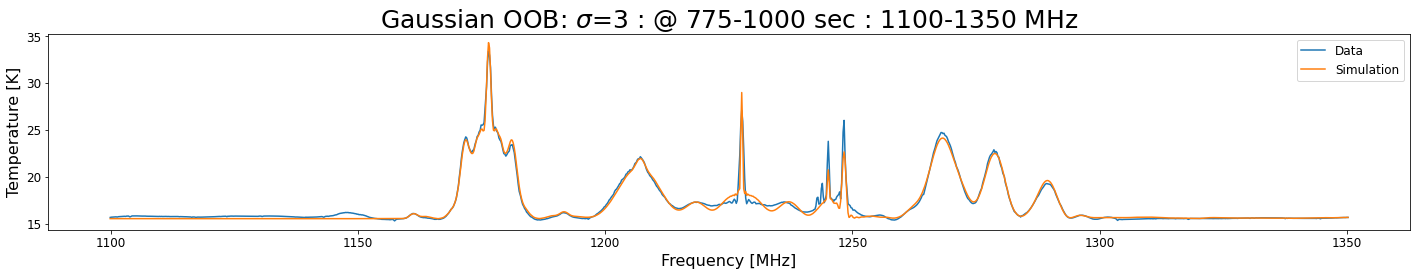

In [22]:

fig, ax = plt.subplots(figsize=(20, 4), nrows=1, ncols=1)

ax.set_title(r'Gaussian OOB: $\sigma$=3 : @ 775-1000 sec : 1100-1350 MHz')

ax.plot(fslice, np.mean(goob_s3_d, axis=0), label='Data')
ax.plot(fslice, np.mean(goob_s3_s, axis=0), label='Simulation')

ax.set_xlabel('Frequency [MHz]')
ax.set_ylabel('Temperature [K]')
ax.legend()
fig.tight_layout()

In [51]:
sat_cat_s3[sat_cat_s3['Frequency[MHz]'] > 1250]

,Sys,Band,Signal,Frequency[MHz],Bandwidth,Modulation,Rate(MHz),P_t (dBW),G_t (dBi),Alpha,Sigma
15,GAL,E6,CS-P(C),1278.75,5.0,BPSK(5),5.1150,16.0,15.0,1.769929,3.0
16,GAL,E6,PRS(A),1278.75,15.0,"BOCcos(10,5)",5.1150,18.0,16.0,1.168449,3.0
20,BDS-2,B3,RS,1268.52,10.0,BPSK(10),10.2300,16.0,16.0,1.685026,3.0
25,BDS-3,B3,B3C-Dm,1268.52,10.0,BPSK(10),10.2300,15.0,13.5,1.000000,3.0
26,BDS-3,B3,B3A-Dm,1268.52,10.0,"BOC(15,2.5)",2.5575,10.0,10.0,2.315622,3.0


### Attenuation: Varied $\sigma$ + 775-1000 seconds + 1100 - 1350 MHz

Varied $\sigma$ for best fits

In [23]:
path = '/users/bengelbrecht/hi_im/brandon/meerkat_gain_cali/1551055211/sat_2/full_1551055211_mask_satellite_f_1000_1500MHz_1100_1350MHz_775_1000_sec_sigma_mix_sig1_v2.p'

goob_sv = pickle.load(open(path, 'rb'))

In [52]:
goob_sv_d, goob_sv_s, goob_sv_chiN, fslice, sat_cat_sv  = chisq_func2(a_param=goob_sv['best-fit'][:21], 
                                                    s_param=goob_sv['best-fit'][21:], damper='goob', 
                                                    frequency_slice=[1100, 1350], time_slice=[ts[0], te[0]], t_mask=False, 
                                                    d_mask=False ,time_avg=False, chi_sigma=False, verbose=False)

No masking applied


In [54]:
print ('Free sigma: '+str(np.round(goob_sv_chiN,5)))
print ('Simga =3: '+str(np.round(goob_s3_chiN,5)))

Free sigma: 0.59556
Simga =3: 0.58256


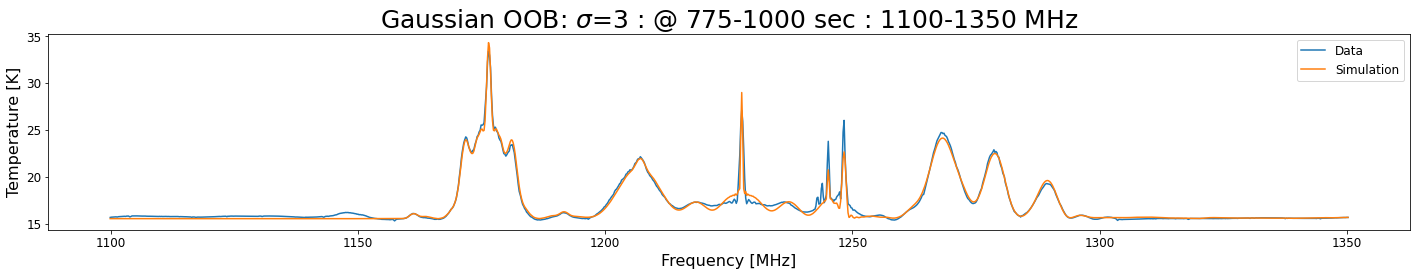

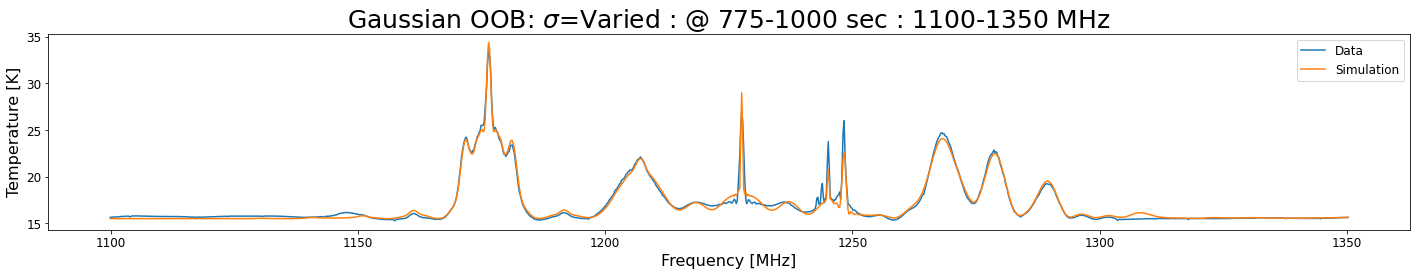

In [55]:

fig, ax = plt.subplots(figsize=(20, 4), nrows=1, ncols=1)

ax.set_title(r'Gaussian OOB: $\sigma$=3 : @ 775-1000 sec : 1100-1350 MHz')

ax.plot(fslice, np.mean(goob_s3_d, axis=0), label='Data')
ax.plot(fslice, np.mean(goob_s3_s, axis=0), label='Simulation')

ax.set_xlabel('Frequency [MHz]')
ax.set_ylabel('Temperature [K]')
ax.legend()
fig.tight_layout()

fig, ax = plt.subplots(figsize=(20, 4), nrows=1, ncols=1)

ax.set_title(r'Gaussian OOB: $\sigma$=Varied : @ 775-1000 sec : 1100-1350 MHz')

ax.plot(fslice, np.mean(goob_sv_d, axis=0), label='Data')
ax.plot(fslice, np.mean(goob_sv_s, axis=0), label='Simulation')

ax.set_xlabel('Frequency [MHz]')
ax.set_ylabel('Temperature [K]')
ax.legend()
fig.tight_layout()

In [33]:
goob_sv['best-fit'][21:]

array([17.47367803, 24.99999962,  5.18819665, 24.99999958, 22.05770021,
       22.62455984, 24.99999958,  4.66933607,  4.29019703,  3.47224358,
       21.23142412, 24.99999958,  0.02925905, 22.75331507,  9.32572548,
        2.85691924, 22.75361525,  0.4714279 , 24.99999958, 24.99999958,
       24.99999958])

In [57]:
sat_cat_sv[sat_cat_sv['Frequency[MHz]'] > 1220]
sat_cat_sv[sat_cat_sv['Frequency[MHz]'] < 1250]


,Sys,Band,Signal,Frequency[MHz],Bandwidth,Modulation,Rate(MHz),P_t (dBW),G_t (dBi),Alpha,Sigma
4,GPS,L2,P(Y),1227.600,10.0,BPSK(10),10.2300,10.0,10.0,1.117575e+01,17.473678
5,GPS,L2,L2CM,1227.600,1.0,BPSK(1),0.5115,10.0,10.0,2.581643e+00,25.000000
6,GPS,L2,M-D,1227.600,15.0,"BOC(10,5)",5.1150,16.0,13.5,9.937512e-01,5.188197
7,GPS,L5,L5I,1176.450,10.0,BPSK(10),10.2300,18.0,18.0,9.695214e-01,25.000000
9,GLO,L2,L2SF(P),1245.100,5.0,BPSK(5),5.1100,10.0,10.0,2.827459e+00,22.057700
10,GLO,L2,L2OF(C/A),1245.100,0.5,BPSK(0.5),0.5110,10.0,10.0,5.688342e-01,22.624560
11,GLO,L3,L3OC-D,1202.025,10.0,BPSK(10),10.2300,10.0,10.0,9.843641e-01,25.000000
12,GLO,L2,L2OC-D,1248.300,1.0,BPSK(1),1.0230,13.0,12.0,6.563773e-01,4.669336
13,GLO,L2,L2OC-P,1248.300,2.0,"BOC(1,1)",0.5115,5.0,5.0,4.154996e-07,4.290197
17,GAL,E5ab,PRS(A),1191.795,25.0,"AltBOC(15,10)",10.2300,10.0,10.0,1.707164e+00,25.000000


##### Best fit $\alpha$ values

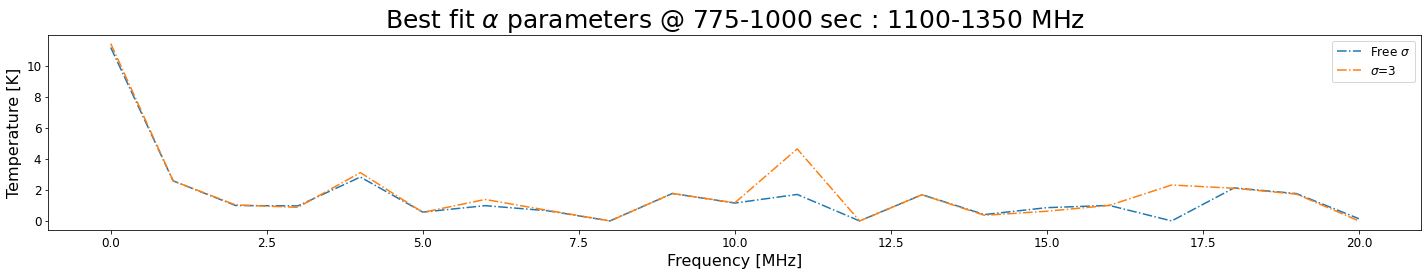

In [32]:
fig, ax = plt.subplots(figsize=(20, 4), nrows=1, ncols=1)

ax.set_title(r'Best fit $\alpha$ parameters @ 775-1000 sec : 1100-1350 MHz')

ax.plot(goob_sv['best-fit'][:21], '-.', label=r'Free $\sigma$')
ax.plot(goob_s3['best-fit'], '-.', label = r'$\sigma$=3')

ax.set_xlabel('Frequency [MHz]')
ax.set_ylabel('Temperature [K]')
ax.legend()
fig.tight_layout()

### Attenuation: 2400-2600 seconds

4 Plots showing the: Data, Simulation no attenuation, Simulation-Goob-3, Simulation-Goob-5

In [ ]:
at_path = '/users/bengelbrecht/hi_im/brandon/meerkat_gain_cali/1551055211/sat_2/'

atten_value = ['','goob_3', 'goob_10']

In [ ]:
times = ts[0], te[0]

print (times)

In [ ]:
## No attenuation

af_file = 'full_no_mask_satellite_f_1000_1500MHz_1100_1350MHz_'+str(times[0])+'_'+str(times[1])+'_sec_'+atten_value[0]+'_sig1_v2.p'
t2_goob_n = pickle.load(open(at_path+af_file, 'rb'))


t2_d, t2_s, t2_chiN, fslice  = chisq_func2(a_param=t2_goob_n['best-fit'], 
                                                    s_param=None, damper=None, 
                                                    frequency_slice=[1100, 1350], time_slice=[times[0], times[1]], t_mask=False, 
                                                    d_mask=False ,time_avg=False, chi_sigma=False, verbose=False)

print ('Chi Square N value: '+str(t2_chiN))

In [ ]:
## GOOB Sigma 3

af_file = 'full_no_mask_satellite_f_1000_1500MHz_1100_1350MHz_'+str(times[0])+'_'+str(times[1])+'_sec_'+atten_value[1]+'_sig1_v2.p'
t2_goob_3 = pickle.load(open(at_path+af_file, 'rb'))


t2_goob_3_d, t2_goob_3_s, t2_goob_3_chiN, fslice  = chisq_func2(a_param=t2_goob_3['best-fit'], 
                                                    s_param=3*np.ones(len(pd.read_csv(pm.satellite_catalogue))), damper='goob', 
                                                    frequency_slice=[1100, 1350], time_slice=[times[0], times[1]], t_mask=False, 
                                                    d_mask=False ,time_avg=False, chi_sigma=False, verbose=False)

print ('Chi Square N value: '+str(t2_goob_3_chiN))

In [21]:
# ## GOOB Sigma 5

# af_file = 'full_no_mask_satellite_f_1000_1500MHz_1100_1350MHz_'+str(times[0])+'_'+str(times[1])+'_sec_'+atten_value[2]+'_sig1_v2.p'
# t2_goob_5 = pickle.load(open(at_path+af_file, 'rb'))


# t2_goob_5_d, t2_goob_5_s, t2_goob_5_chiN, fslice  = chisq_func2(a_param=t2_goob_5['best-fit'], 
#                                                     s_param=5*np.ones(len(pd.read_csv(pm.satellite_catalogue))), damper='goob', 
#                                                     frequency_slice=[1100, 1350], time_slice=[times[0], times[1]], t_mask=False, 
#                                                     d_mask=False ,time_avg=False, chi_sigma=False, verbose=False)

# print ('Chi Square N value: '+str(t2_goob_5_chiN))

No masking applied
Chi Square N value: 1.0685689356580537


In [ ]:
## GOOB Sigma 10

af_file = 'full_no_mask_satellite_f_1000_1500MHz_1100_1350MHz_'+str(times[0])+'_'+str(times[1])+'_sec_'+atten_value[3]+'_sig1_v2.p'
t2_goob_10 = pickle.load(open(at_path+af_file, 'rb'))


t2_goob_10_d, t2_goob_10_s, t2_goob_10_chiN, fslice  = chisq_func2(a_param=t2_goob_10['best-fit'], 
                                                    s_param=10*np.ones(len(pd.read_csv(pm.satellite_catalogue))), damper='goob', 
                                                    frequency_slice=[1100, 1350], time_slice=[times[0], times[1]], t_mask=False, 
                                                    d_mask=False ,time_avg=False, chi_sigma=False, verbose=False)

print ('Chi Square N value: '+str(t2_goob_10_chiN))

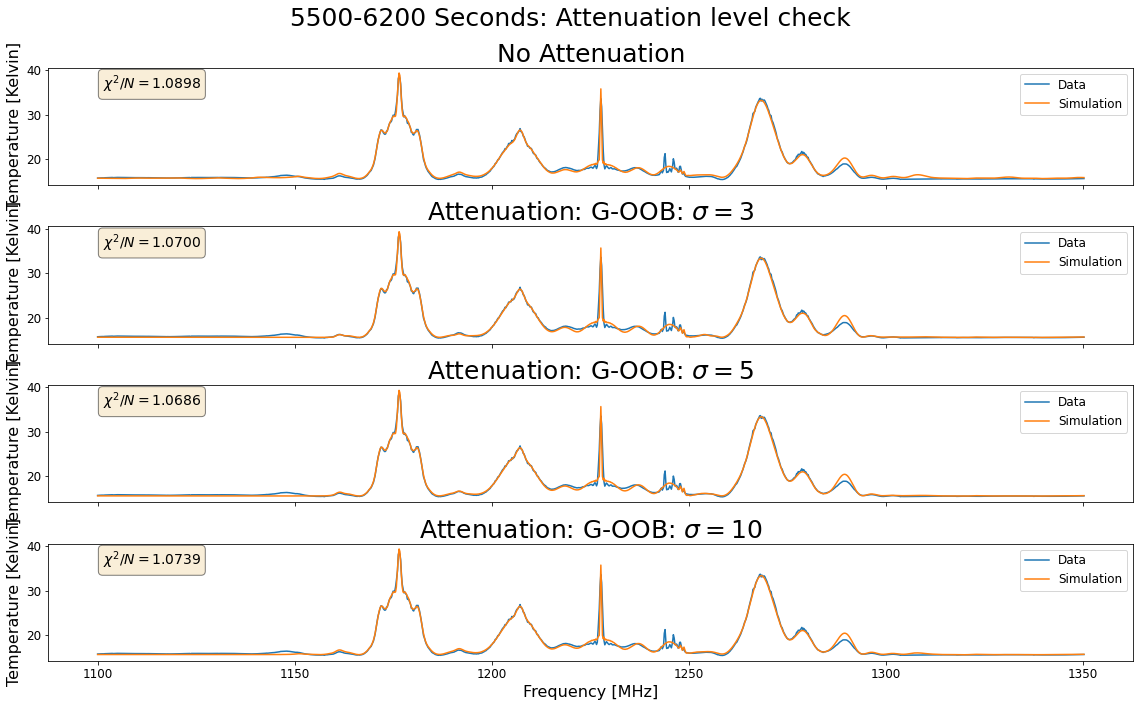

In [28]:
fig, axs = plt.subplots(figsize=(16, 10), nrows = 4, ncols=1, sharey=True, sharex=True)
fig.suptitle(str(times[0])+'-'+str(times[1])+' Seconds: Attenuation level check')

ax=axs[0]
ax.plot(fslice, np.ma.mean(t2_d, axis=0), label='Data')
ax.plot(fslice, np.ma.mean(t2_s, axis=0), label='Simulation')
ax.set_title('No Attenuation')
ax.set_ylabel('Temperature [Kelvin]')
ax.legend()

textstr = '\n'.join((
    r'$\chi^2/N=%.4f$' % (np.round(t2_chiN, 4), ),))

props = dict(boxstyle='round', facecolor='wheat', alpha=0.5)
# place a text box in upper left in axes coords
ax.text(0.05, 0.95, textstr, transform=ax.transAxes, fontsize=14,
        verticalalignment='top', bbox=props)



ax=axs[1]
ax.plot(fslice, np.ma.mean(t2_goob_3_d, axis=0), label='Data')
ax.plot(fslice, np.ma.mean(t2_goob_3_s, axis=0), label='Simulation')
ax.set_title(r'Attenuation: G-OOB: $\sigma=3$')
ax.set_ylabel('Temperature [Kelvin]')
ax.legend()

textstr = '\n'.join((
    r'$\chi^2/N=%.4f$' % (np.round(t2_goob_3_chiN, 4), ),))

props = dict(boxstyle='round', facecolor='wheat', alpha=0.5)
# place a text box in upper left in axes coords
ax.text(0.05, 0.95, textstr, transform=ax.transAxes, fontsize=14,
        verticalalignment='top', bbox=props)


ax=axs[2]
ax.plot(fslice, np.ma.mean(t2_goob_5_d, axis=0), label='Data')
ax.plot(fslice, np.ma.mean(t2_goob_5_s, axis=0), label='Simulation')
ax.set_title(r'Attenuation: G-OOB: $\sigma=5$')
ax.set_ylabel('Temperature [Kelvin]')
ax.legend()

textstr = '\n'.join((
    r'$\chi^2/N=%.4f$' % (np.round(t2_goob_5_chiN, 4), ),))

props = dict(boxstyle='round', facecolor='wheat', alpha=0.5)
# place a text box in upper left in axes coords
ax.text(0.05, 0.95, textstr, transform=ax.transAxes, fontsize=14,
        verticalalignment='top', bbox=props)

ax=axs[3]
ax.plot(fslice, np.ma.mean(t2_goob_10_d, axis=0), label='Data')
ax.plot(fslice, np.ma.mean(t2_goob_10_s, axis=0), label='Simulation')
ax.set_title(r'Attenuation: G-OOB: $\sigma=10$')
ax.set_xlabel('Frequency [MHz]')
ax.set_ylabel('Temperature [Kelvin]')
ax.legend()

textstr = '\n'.join((
    r'$\chi^2/N=%.4f$' % (np.round(t2_goob_10_chiN, 4), ),))

props = dict(boxstyle='round', facecolor='wheat', alpha=0.5)
# place a text box in upper left in axes coords
ax.text(0.05, 0.95, textstr, transform=ax.transAxes, fontsize=14,
        verticalalignment='top', bbox=props)

fig.tight_layout()

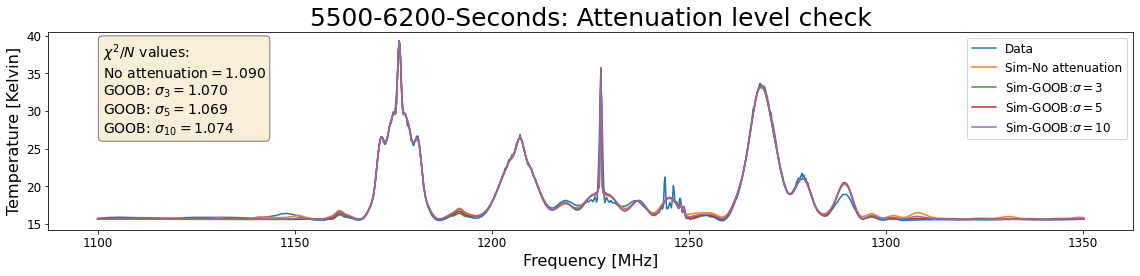

In [26]:
fig, axs = plt.subplots(figsize=(16, 4), nrows = 1, ncols=1, sharey=True)

ax=axs
ax.plot(fslice, np.ma.mean(t2_d, axis=0), label='Data')
ax.plot(fslice, np.ma.mean(t2_s, axis=0), label='Sim-No attenuation')
ax.plot(fslice, np.ma.mean(t2_goob_3_s, axis=0), label=r'Sim-GOOB:$\sigma=3$')
ax.plot(fslice, np.ma.mean(t2_goob_5_s, axis=0), label=r'Sim-GOOB:$\sigma=5$')
ax.plot(fslice, np.ma.mean(t2_goob_10_s, axis=0), label=r'Sim-GOOB:$\sigma=10$')


textstr = '\n'.join((
    r'$\chi^2/N$ values:',
    r'No attenuation$=%.3f$' % (np.round(t2_chiN, 4), ),
    r'GOOB: $\sigma_{3}=%.3f$' % (np.round(t2_goob_3_chiN, 4), ),
    r'GOOB: $\sigma_{5}=%.3f$' % (np.round(t2_goob_5_chiN, 4), ),
    r'GOOB: $\sigma_{10}=%.3f$' % (np.round(t2_goob_10_chiN, 4), ),))


props = dict(boxstyle='round', facecolor='wheat', alpha=0.5)
# place a text box in upper left in axes coords
ax.text(0.05, 0.95, textstr, transform=ax.transAxes, fontsize=14,
        verticalalignment='top', bbox=props)

ax.set_title(str(times[0])+'-'+str(times[1])+'-'+'Seconds: Attenuation level check')
ax.set_xlabel('Frequency [MHz]')
ax.set_ylabel('Temperature [Kelvin]')
ax.legend()

fig.tight_layout()

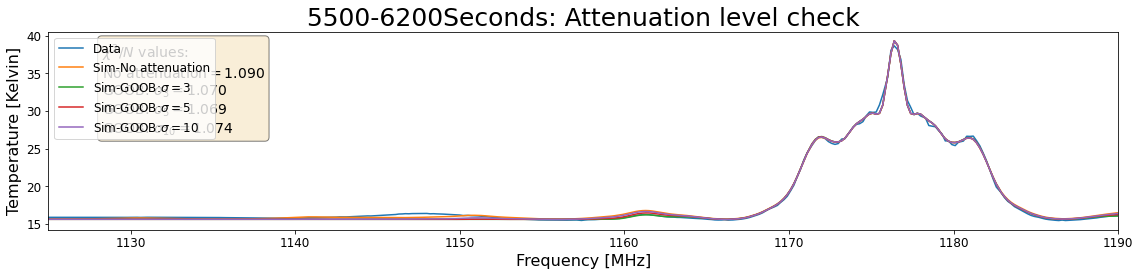

In [27]:
fig, axs = plt.subplots(figsize=(16, 4), nrows = 1, ncols=1, sharey=True)

ax=axs
ax.plot(fslice, np.ma.mean(t2_d, axis=0), label='Data')
ax.plot(fslice, np.ma.mean(t2_s, axis=0), label='Sim-No attenuation')
ax.plot(fslice, np.ma.mean(t2_goob_3_s, axis=0), label=r'Sim-GOOB:$\sigma=3$')
ax.plot(fslice, np.ma.mean(t2_goob_5_s, axis=0), label=r'Sim-GOOB:$\sigma=5$')
ax.plot(fslice, np.ma.mean(t2_goob_10_s, axis=0), label=r'Sim-GOOB:$\sigma=10$')

ax.set_xlim(1125, 1190)

textstr = '\n'.join((
    r'$\chi^2/N$ values:',
    r'No attenuation$=%.3f$' % (np.round(t2_chiN, 4), ),
    r'GOOB: $\sigma_{3}=%.3f$' % (np.round(t2_goob_3_chiN, 4), ),
    r'GOOB: $\sigma_{5}=%.3f$' % (np.round(t2_goob_5_chiN, 4), ),
    r'GOOB: $\sigma_{10}=%.3f$' % (np.round(t2_goob_10_chiN, 4), ),))


props = dict(boxstyle='round', facecolor='wheat', alpha=0.5)
# place a text box in upper left in axes coords
ax.text(0.05, 0.95, textstr, transform=ax.transAxes, fontsize=14,
        verticalalignment='top', bbox=props)

ax.set_title(str(times[0])+'-'+str(times[1])+'Seconds: Attenuation level check')
ax.set_xlabel('Frequency [MHz]')
ax.set_ylabel('Temperature [Kelvin]')
ax.legend()

fig.tight_layout()